# Observations

We have historic time series for the three crops in the study – maize, beans and sorghum. For 1999-2022 we have official data from El Salvador, and for 1961-2023 we have FAO data. The data gives the yield for each crop (in kg/ha – we have converted the units from the original data where required) for the country.

This notebook reads them in, visualizes them, harmonizes them, and then calculates yield anomalies, which will be used in the calibration. 

In [1]:
from pathlib import Path

# -----------------------------------------------
# Set up paths to data
# -----------------------------------------------

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILE = "observations_raw.csv"
observations_filepath = Path(OBSERVATIONS_DIR) / OBSERVATIONS_FILE


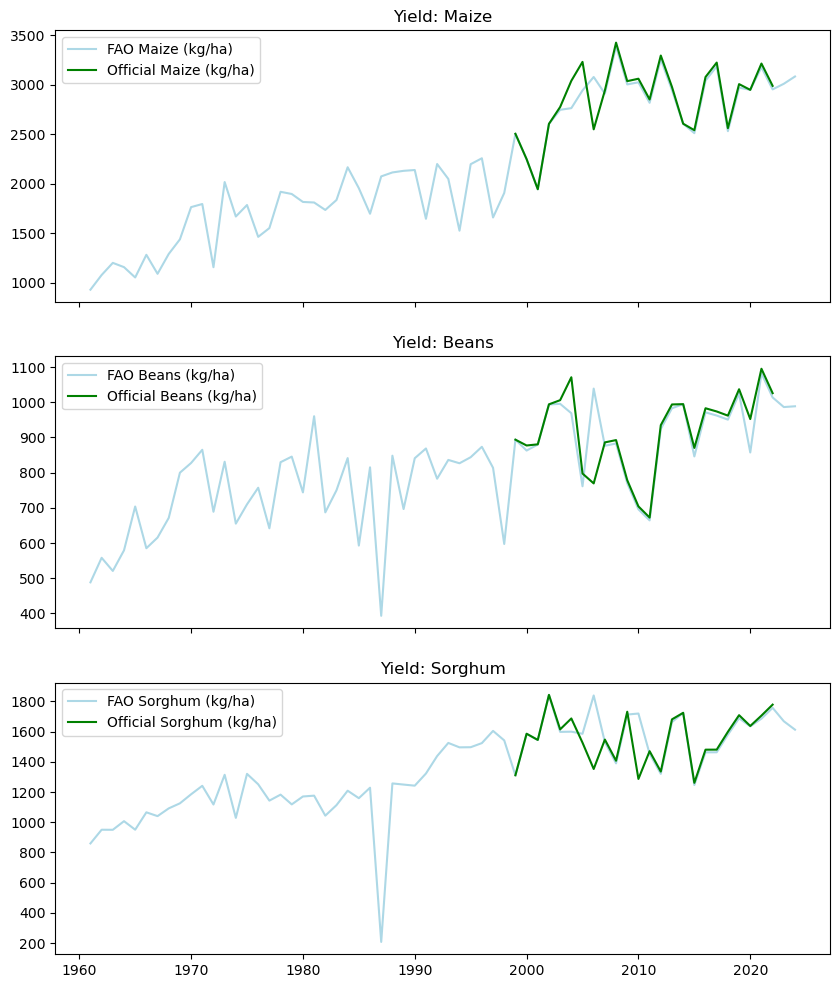

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------------------------
# Read and plot the raw observations
# -----------------------------------------------

obs = pd.read_csv(observations_filepath)

# Plot the two time series we have for each crop:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for i, crop in enumerate(["Maize", "Beans", "Sorghum"]):
    official_col = f"Official {crop} (kg/ha)"
    fao_col = f"FAO {crop} (kg/ha)"
    axes[i].plot(obs['Year'], obs[fao_col], label=fao_col, color="lightblue")
    axes[i].plot(obs['Year'], obs[official_col], label=official_col, color="green")
    axes[i].set_title(f"Yield: {crop}")
    axes[i].legend()


While the plot time series mostly agree, there are some differences in the overlapping years. The FAO data claims to report the official country statistics and should agree. Without more in-depth research we con't explain this: it could be due to one dataset revising statistics with more information in later years, or due to reporting periods (since crops may have more than one growing season), or some other reason.

We choose to take the official statistics when available, and use the FAO data in other years.

In [3]:
# -----------------------------------------------
# Harmonize the observations
# -----------------------------------------------

# Take official data when we have it, and use FAO otherwise
for crop in ["Maize", "Beans", "Sorghum"]:
    official_col = f"Official {crop} (kg/ha)"
    fao_col = f"FAO {crop} (kg/ha)"

    harmonized = [x if not pd.isna(x) else y for x, y in zip(obs[official_col], obs[fao_col])]
    harmonized_col = f"Harmonized {crop} (kg/ha)"
    obs[harmonized_col] = harmonized

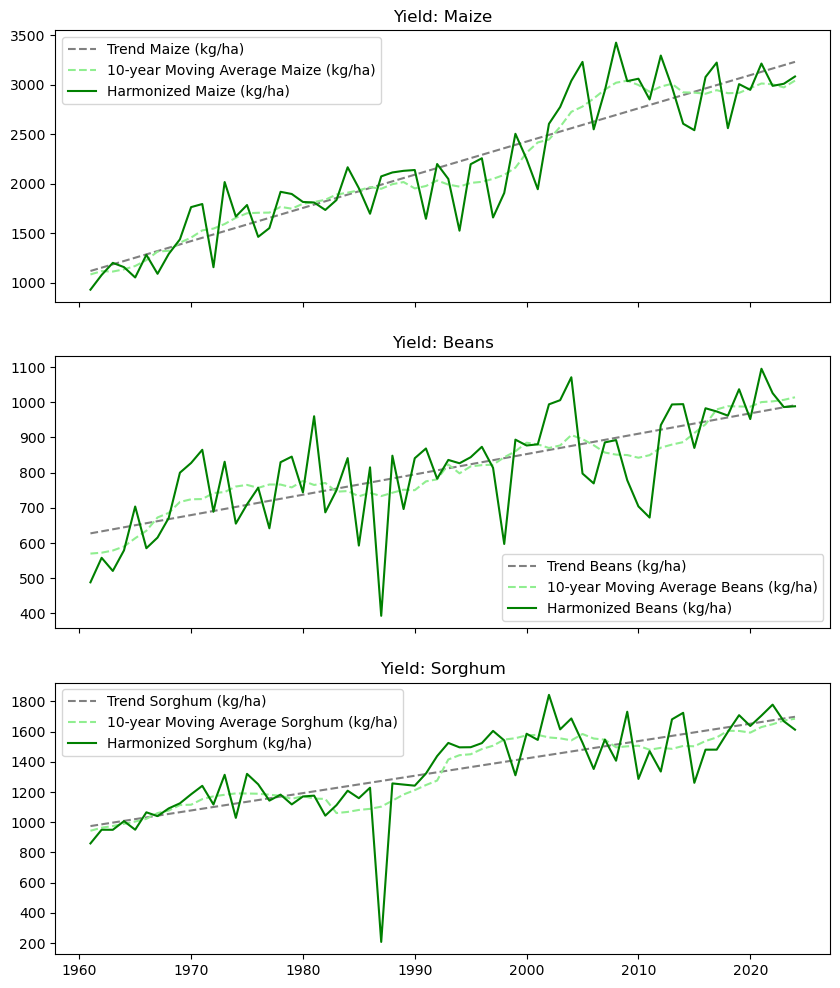

In [4]:
# -----------------------------------------------
# Calculate yield anomalies
# -----------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i, crop in enumerate(["Maize", "Beans", "Sorghum"]):
    harmonized_col = f"Harmonized {crop} (kg/ha)"

    # Fit a linear model to the harmonized column
    trend, intercept = np.polyfit(obs['Year'], obs[harmonized_col], 1)
    trend_values = trend * obs['Year'] + intercept
    trend_col = f"Trend {crop} (kg/ha)"
    obs[trend_col] = trend_values


    # Calculate 10-year moving average of the harmonized column centered on the current year
    # We won't use this, but it's another option for calculating anomalous yields
    moving_avg_col = f"10-year Moving Average {crop} (kg/ha)"
    obs[moving_avg_col] = obs[harmonized_col].rolling(window=10, min_periods=1, center=True).mean()

    # Calculate absoute yield anomaly relative to the average
    anomaly = obs[harmonized_col] - obs[trend_col]
    anomaly_col = f"Yield Anomaly {crop} (kg/ha)"
    obs[anomaly_col] = anomaly
    
    # Calculate relative yield anomaly
    anomaly_fraction = anomaly / obs[trend_col]
    anomaly_fraction_col = f"Yield Anomaly {crop} (fraction)"
    obs[anomaly_fraction_col] = anomaly_fraction

    # Use the trend to scale historic yields to 2023 levels
    obs[f"2023-equivalent yield {crop} (kg/ha)"] = obs[harmonized_col] * obs[trend_col].iloc[-1] / obs[trend_col]
    obs[f"2023-equivalent anomaly {crop} (kg/ha)"] = obs[anomaly_col] * obs[trend_col].iloc[-1] / obs[trend_col]

    # Plot
    axes[i].plot(obs['Year'], obs[trend_col], label=trend_col, color="grey", linestyle="--")
    axes[i].plot(obs['Year'], obs[moving_avg_col], label=moving_avg_col, color="lightgreen", linestyle="--")
    axes[i].plot(obs['Year'], obs[harmonized_col], label=harmonized_col, color="green")
    axes[i].legend()
    axes[i].set_title(f"Yield: {crop}")


In [ ]:
# -----------------------------------------------
# Save to file
# -----------------------------------------------

all_vars = [["Year"]]
for crop in ["Maize", "Beans", "Sorghum"]:
    varnames = [
        f"Official {crop} (kg/ha)",
        f"FAO {crop} (kg/ha)",
        f"Harmonized {crop} (kg/ha)",
        f"Trend {crop} (kg/ha)",
        f"10-year Moving Average {crop} (kg/ha)",
        f"Yield Anomaly {crop} (kg/ha)",
        f"Yield Anomaly {crop} (fraction)",
        f"2023-equivalent yield {crop} (kg/ha)",
        f"2023-equivalent anomaly {crop} (kg/ha)"
    ]
    all_vars.append(varnames)

# Flatten the list of lists
all_vars = [item for sublist in all_vars for item in sublist]

obs = obs[all_vars]
obs = obs.round(2)  # Round all values to 2 decimal places - nothing needs to be more precise than this, and it makes it easier to read
display(obs.head())

obs.to_csv(Path(OBSERVATIONS_DIR) / "observations.csv", index=False)

,Year,Official Maize (kg/ha),FAO Maize (kg/ha),Harmonized Maize (kg/ha),Trend Maize (kg/ha),10-year Moving Average Maize (kg/ha),Yield Anomaly Maize (kg/ha),Yield Anomaly Maize (fraction),2023-equivalent yield Maize (kg/ha),2023-equivalent anomaly Maize (kg/ha),...,2023-equivalent anomaly Beans (kg/ha),Official Sorghum (kg/ha),FAO Sorghum (kg/ha),Harmonized Sorghum (kg/ha),Trend Sorghum (kg/ha),10-year Moving Average Sorghum (kg/ha),Yield Anomaly Sorghum (kg/ha),Yield Anomaly Sorghum (fraction),2023-equivalent yield Sorghum (kg/ha),2023-equivalent anomaly Sorghum (kg/ha)
0,1961,NaN,927.9,927.9,1117.13,1082.20,-189.23,-0.17,2684.78,-547.52,...,-219.85,NaN,859.8,859.8,974.79,943.66,-114.99,-0.12,1498.17,-200.37
1,1962,NaN,1076.5,1076.5,1150.70,1115.30,-74.20,-0.06,3023.86,-208.44,...,-117.75,NaN,950.5,950.5,986.28,964.02,-35.78,-0.04,1636.92,-61.61
2,1963,NaN,1199.2,1199.2,1184.28,1111.47,14.92,0.01,3273.02,40.73,...,-183.53,NaN,950.1,950.1,997.77,974.96,-47.67,-0.05,1617.39,-81.14
3,1964,NaN,1156.0,1156.0,1217.85,1133.71,-61.85,-0.05,3068.13,-164.16,...,-100.80,NaN,1007.2,1007.2,1009.25,989.58,-2.05,-0.00,1695.08,-3.46
4,1965,NaN,1051.4,1051.4,1251.43,1167.43,-200.03,-0.16,2715.65,-516.65,...,81.04,NaN,950.7,950.7,1020.74,1004.67,-70.04,-0.07,1581.98,-116.55
